# Sistem Rekomendasi Produk Tokopedia

## 1. Research Goal (Tujuan Penelitian)

**Problem Statement:**
Pengguna e-commerce seringkali kesulitan menemukan produk yang relevan di antara jutaan produk yang tersedia. Sistem rekomendasi yang baik dapat meningkatkan pengalaman belanja dan konversi penjualan.

**Tujuan Proyek:**
Membangun sistem rekomendasi produk berbasis *content-based filtering* menggunakan dataset Tokopedia, dengan pendekatan:
1. **TF-IDF + Cosine Similarity** — merekomendasikan produk berdasarkan kemiripan konten (nama, kategori, lokasi toko).
2. **Hybrid Ranking** — menggabungkan skor kemiripan konten dengan skor popularitas (rating & jumlah terjual).

**Pertanyaan Penelitian:**
- Produk mana yang paling mirip dengan produk yang sedang dilihat pengguna?
- Bagaimana menggabungkan relevansi konten dengan popularitas untuk menghasilkan rekomendasi yang lebih baik?

**Dataset:**
- Sumber: https://www.kaggle.com/datasets/musabiam/tokopedia-product-and-review-dataset)
- Format: CSV (`tokopedia_product_with_review.csv`)
- Fitur utama: `name`, `category`, `price`, `rating_average`, `count_sold`, `shop_location`, `gold_merchant`, `is_official`

**Project Charter:**
| Item | Detail |
|------|--------|
| Metode | Content-Based Filtering (TF-IDF) + Hybrid Ranking |
| Tools | Python, Pandas, Scikit-learn, Matplotlib, Seaborn |
| Output | Fungsi rekomendasi by product_id, by name, dan hybrid |
| Evaluasi | Precision@K (proxy: kesamaan kategori) |

In [ ]:
!pip -q install gdown

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
import ast
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

In [ ]:
# =========================
# 1. DOWNLOAD / LOAD DATA
# =========================
url = "https://drive.google.com/uc?id=1UVG7FPebrQVnSDr-XspuFkDA4vFEPzK1"
output = "tokopedia_product_with_review.csv"
gdown.download(url, output, quiet=False)

df = pd.read_csv('/content/tokopedia_product_with_review.csv')
display(df.head())

print(df.shape)
display(df.head())
df.info()

Downloading...
From (original): https://drive.google.com/uc?id=1UVG7FPebrQVnSDr-XspuFkDA4vFEPzK1
From (redirected): https://drive.google.com/uc?id=1UVG7FPebrQVnSDr-XspuFkDA4vFEPzK1&confirm=t&uuid=dde93943-7576-4baf-8f12-999d5b4cc0e6
To: /content/tokopedia_product_with_review.csv
100%|██████████| 362M/362M [00:02<00:00, 122MB/s] 


,product_id,category,name,count_sold,discounted_price,preorder,price,stock,gold_merchant,is_official,is_topads,rating_average,shop_id,shop_location,warehouse_id,product_url,review_id,variant_name,message,review_rating,review_time,review_timestamp,review_response,review_like,bad_rating_reason
0,268823794,rumah_tangga|storage_fair,Ambalan Laci Melayang 60x20x5.5 MERK KINBAR A543,2112.0,NaN,False,108500,295,True,False,False,4.8,289567,Kota Administrasi Jakarta Barat,265620.0,https://www.tokopedia.com/mega-persada/ambalan-laci-melayang-60x20x5-5-merk-kinbar-a543,"['1587995048', '1572236924', '1330433454', '1117774503', '1111292478', '1095856533', '1080398680', '1068731930', '99...","['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '',...","['goodboy', 'Produk telah diterima dalam keadaan baik dan sesuai deskripsi.', 'respon penjual baik dan cepat ,kirima...","[5, 5, 5, 5, 5, 1, 3, 5, 5, 5, 5, 5, 5, 5, 5, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5...","['1753321151', '1752470614', '1742575219', '1731408393', '1730128188', '1726987877', '1723892106', '1721588593', '17...","['4 bulan lalu', '4 bulan lalu', '8 bulan lalu', 'Lebih dari 1 tahun lalu', 'Lebih dari 1 tahun lalu', 'Lebih dari 1...",['Terima kasih telah berbelanja di Mega-Persada. Bagikan link toko kami https://www.tokopedia.com/mega-persada kepad...,"[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","['', '', '', '', '', 'Kendala: Tidak lengkap/salah kirim', 'Kendala: Kualitas barang bermasalah', '', '', '', '', ''..."
1,2145556006,rumah_tangga|storage_fair,Daiso Storage Box with Lid -,285.0,NaN,False,33000,1,True,True,False,5.0,12064541,Kota Administrasi Jakarta Selatan,12013404.0,https://www.tokopedia.com/daiso-japan/daiso-storage-box-with-lid,"['1548475223', '1329468255', '1302218079', '1296793605', '1142041045', '1136642136', '1131914027', '1128882991', '10...","['', '', '', '', '', '', '', '', '', '', '', '', '', '', '']","['Lucu kotak nya. Bahan juga kokoh.Terima kasih:', 'Kualitas barang sesuai dengan deskripsi produk, Thank you ...', ...","[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]","['1751300951', '1742542078', '1741368517', '1741116518', '1736713378', '1735423002', '1734467164', '1733856052', '17...","['5 bulan lalu', '8 bulan lalu', '8 bulan lalu', '8 bulan lalu', '10 bulan lalu', '11 bulan lalu', '11 bulan lalu', ...",['Terima kasih telah berbelanja di Daiso Japan Official Store. Bagikan link toko kami https://www.tokopedia.com/dais...,"[0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 1]","['', '', '', '', '', '', '', '', '', '', '', '', '', '', '']"
2,1276550898,rumah_tangga|storage_fair,Shinpo 204 Kotak Box Tempat Masker Pensil Penyimpanan Serbaguna Kawaii,3686.0,NaN,False,9300,6853,True,False,False,4.9,746490,Kota Administrasi Jakarta Barat,405511.0,https://www.tokopedia.com/miraclestar/shinpo-204-kotak-box-tempat-masker-pensil-penyimpanan-serbaguna-kawaii,"['1773985424', '1204731599', '1146722203', '1086479517', '998047699', '894238952', '885246048', '860953909', '856269...","['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '',...","['', 'alhmdulillah 25pcs telah meluncur sampai tujuan dengan baik,, sesuai jumlah,, makasih toko yg amanah', 'respon...","[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 1, 5, 5, 5, 3, 5, 5, 5, 5, 4, 4, 1, 5, 5, 5, 5, 5, 5, 5, 4, 5, 5, 5, 5, 5...","['1763542549', '1739817200', '1737818855', '1725148000', '1707030154', '1684995214', '1683249537', '1678798184', '16...","['1 minggu lalu', '9 bulan lalu', '10 bulan lalu', 'Lebih dari 1 tahun lalu', 'Lebih dari 1 tahun lalu', 'Lebih dari...",['Terima kasih telah berbelanja di MiracleStar. Bagikan link toko kami https://www.tokopedia.com/MiracleStar-998 kep...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

(5553, 25)


,product_id,category,name,count_sold,discounted_price,preorder,price,stock,gold_merchant,is_official,is_topads,rating_average,shop_id,shop_location,warehouse_id,product_url,review_id,variant_name,message,review_rating,review_time,review_timestamp,review_response,review_like,bad_rating_reason
0,268823794,rumah_tangga|storage_fair,Ambalan Laci Melayang 60x20x5.5 MERK KINBAR A543,2112.0,NaN,False,108500,295,True,False,False,4.8,289567,Kota Administrasi Jakarta Barat,265620.0,https://www.tokopedia.com/mega-persada/ambalan-laci-melayang-60x20x5-5-merk-kinbar-a543,"['1587995048', '1572236924', '1330433454', '1117774503', '1111292478', '1095856533', '1080398680', '1068731930', '99...","['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '',...","['goodboy', 'Produk telah diterima dalam keadaan baik dan sesuai deskripsi.', 'respon penjual baik dan cepat ,kirima...","[5, 5, 5, 5, 5, 1, 3, 5, 5, 5, 5, 5, 5, 5, 5, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5...","['1753321151', '1752470614', '1742575219', '1731408393', '1730128188', '1726987877', '1723892106', '1721588593', '17...","['4 bulan lalu', '4 bulan lalu', '8 bulan lalu', 'Lebih dari 1 tahun lalu', 'Lebih dari 1 tahun lalu', 'Lebih dari 1...",['Terima kasih telah berbelanja di Mega-Persada. Bagikan link toko kami https://www.tokopedia.com/mega-persada kepad...,"[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","['', '', '', '', '', 'Kendala: Tidak lengkap/salah kirim', 'Kendala: Kualitas barang bermasalah', '', '', '', '', ''..."
1,2145556006,rumah_tangga|storage_fair,Daiso Storage Box with Lid -,285.0,NaN,False,33000,1,True,True,False,5.0,12064541,Kota Administrasi Jakarta Selatan,12013404.0,https://www.tokopedia.com/daiso-japan/daiso-storage-box-with-lid,"['1548475223', '1329468255', '1302218079', '1296793605', '1142041045', '1136642136', '1131914027', '1128882991', '10...","['', '', '', '', '', '', '', '', '', '', '', '', '', '', '']","['Lucu kotak nya. Bahan juga kokoh.Terima kasih:', 'Kualitas barang sesuai dengan deskripsi produk, Thank you ...', ...","[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]","['1751300951', '1742542078', '1741368517', '1741116518', '1736713378', '1735423002', '1734467164', '1733856052', '17...","['5 bulan lalu', '8 bulan lalu', '8 bulan lalu', '8 bulan lalu', '10 bulan lalu', '11 bulan lalu', '11 bulan lalu', ...",['Terima kasih telah berbelanja di Daiso Japan Official Store. Bagikan link toko kami https://www.tokopedia.com/dais...,"[0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 1]","['', '', '', '', '', '', '', '', '', '', '', '', '', '', '']"
2,1276550898,rumah_tangga|storage_fair,Shinpo 204 Kotak Box Tempat Masker Pensil Penyimpanan Serbaguna Kawaii,3686.0,NaN,False,9300,6853,True,False,False,4.9,746490,Kota Administrasi Jakarta Barat,405511.0,https://www.tokopedia.com/miraclestar/shinpo-204-kotak-box-tempat-masker-pensil-penyimpanan-serbaguna-kawaii,"['1773985424', '1204731599', '1146722203', '1086479517', '998047699', '894238952', '885246048', '860953909', '856269...","['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '',...","['', 'alhmdulillah 25pcs telah meluncur sampai tujuan dengan baik,, sesuai jumlah,, makasih toko yg amanah', 'respon...","[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 1, 5, 5, 5, 3, 5, 5, 5, 5, 4, 4, 1, 5, 5, 5, 5, 5, 5, 5, 4, 5, 5, 5, 5, 5...","['1763542549', '1739817200', '1737818855', '1725148000', '1707030154', '1684995214', '1683249537', '1678798184', '16...","['1 minggu lalu', '9 bulan lalu', '10 bulan lalu', 'Lebih dari 1 tahun lalu', 'Lebih dari 1 tahun lalu', 'Lebih dari...",['Terima kasih telah berbelanja di MiracleStar. Bagikan link toko kami https://www.tokopedia.com/MiracleStar-998 kep...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5553 entries, 0 to 5552
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   product_id         5553 non-null   int64  
 1   category           5553 non-null   object 
 2   name               5553 non-null   object 
 3   count_sold         4743 non-null   float64
 4   discounted_price   1340 non-null   float64
 5   preorder           5553 non-null   bool   
 6   price              5553 non-null   int64  
 7   stock              5553 non-null   int64  
 8   gold_merchant      5553 non-null   bool   
 9   is_official        5553 non-null   bool   
 10  is_topads          5553 non-null   bool   
 11  rating_average     5487 non-null   float64
 12  shop_id            5553 non-null   int64  
 13  shop_location      5526 non-null   object 
 14  warehouse_id       4759 non-null   float64
 15  product_url        5553 non-null   object 
 16  review_id          5553 

In [ ]:
# =========================
# 2. QUICK CHECK
# =========================
print(df.shape)
display(df.head())
df.info()

(5553, 25)


,product_id,category,name,count_sold,discounted_price,preorder,price,stock,gold_merchant,is_official,is_topads,rating_average,shop_id,shop_location,warehouse_id,product_url,review_id,variant_name,message,review_rating,review_time,review_timestamp,review_response,review_like,bad_rating_reason
0,268823794,rumah_tangga|storage_fair,Ambalan Laci Melayang 60x20x5.5 MERK KINBAR A543,2112.0,NaN,False,108500,295,True,False,False,4.8,289567,Kota Administrasi Jakarta Barat,265620.0,https://www.tokopedia.com/mega-persada/ambalan-laci-melayang-60x20x5-5-merk-kinbar-a543,"['1587995048', '1572236924', '1330433454', '1117774503', '1111292478', '1095856533', '1080398680', '1068731930', '99...","['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '',...","['goodboy', 'Produk telah diterima dalam keadaan baik dan sesuai deskripsi.', 'respon penjual baik dan cepat ,kirima...","[5, 5, 5, 5, 5, 1, 3, 5, 5, 5, 5, 5, 5, 5, 5, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5...","['1753321151', '1752470614', '1742575219', '1731408393', '1730128188', '1726987877', '1723892106', '1721588593', '17...","['4 bulan lalu', '4 bulan lalu', '8 bulan lalu', 'Lebih dari 1 tahun lalu', 'Lebih dari 1 tahun lalu', 'Lebih dari 1...",['Terima kasih telah berbelanja di Mega-Persada. Bagikan link toko kami https://www.tokopedia.com/mega-persada kepad...,"[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","['', '', '', '', '', 'Kendala: Tidak lengkap/salah kirim', 'Kendala: Kualitas barang bermasalah', '', '', '', '', ''..."
1,2145556006,rumah_tangga|storage_fair,Daiso Storage Box with Lid -,285.0,NaN,False,33000,1,True,True,False,5.0,12064541,Kota Administrasi Jakarta Selatan,12013404.0,https://www.tokopedia.com/daiso-japan/daiso-storage-box-with-lid,"['1548475223', '1329468255', '1302218079', '1296793605', '1142041045', '1136642136', '1131914027', '1128882991', '10...","['', '', '', '', '', '', '', '', '', '', '', '', '', '', '']","['Lucu kotak nya. Bahan juga kokoh.Terima kasih:', 'Kualitas barang sesuai dengan deskripsi produk, Thank you ...', ...","[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]","['1751300951', '1742542078', '1741368517', '1741116518', '1736713378', '1735423002', '1734467164', '1733856052', '17...","['5 bulan lalu', '8 bulan lalu', '8 bulan lalu', '8 bulan lalu', '10 bulan lalu', '11 bulan lalu', '11 bulan lalu', ...",['Terima kasih telah berbelanja di Daiso Japan Official Store. Bagikan link toko kami https://www.tokopedia.com/dais...,"[0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 1]","['', '', '', '', '', '', '', '', '', '', '', '', '', '', '']"
2,1276550898,rumah_tangga|storage_fair,Shinpo 204 Kotak Box Tempat Masker Pensil Penyimpanan Serbaguna Kawaii,3686.0,NaN,False,9300,6853,True,False,False,4.9,746490,Kota Administrasi Jakarta Barat,405511.0,https://www.tokopedia.com/miraclestar/shinpo-204-kotak-box-tempat-masker-pensil-penyimpanan-serbaguna-kawaii,"['1773985424', '1204731599', '1146722203', '1086479517', '998047699', '894238952', '885246048', '860953909', '856269...","['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '',...","['', 'alhmdulillah 25pcs telah meluncur sampai tujuan dengan baik,, sesuai jumlah,, makasih toko yg amanah', 'respon...","[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 1, 5, 5, 5, 3, 5, 5, 5, 5, 4, 4, 1, 5, 5, 5, 5, 5, 5, 5, 4, 5, 5, 5, 5, 5...","['1763542549', '1739817200', '1737818855', '1725148000', '1707030154', '1684995214', '1683249537', '1678798184', '16...","['1 minggu lalu', '9 bulan lalu', '10 bulan lalu', 'Lebih dari 1 tahun lalu', 'Lebih dari 1 tahun lalu', 'Lebih dari...",['Terima kasih telah berbelanja di MiracleStar. Bagikan link toko kami https://www.tokopedia.com/MiracleStar-998 kep...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5553 entries, 0 to 5552
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   product_id         5553 non-null   int64  
 1   category           5553 non-null   object 
 2   name               5553 non-null   object 
 3   count_sold         4743 non-null   float64
 4   discounted_price   1340 non-null   float64
 5   preorder           5553 non-null   bool   
 6   price              5553 non-null   int64  
 7   stock              5553 non-null   int64  
 8   gold_merchant      5553 non-null   bool   
 9   is_official        5553 non-null   bool   
 10  is_topads          5553 non-null   bool   
 11  rating_average     5487 non-null   float64
 12  shop_id            5553 non-null   int64  
 13  shop_location      5526 non-null   object 
 14  warehouse_id       4759 non-null   float64
 15  product_url        5553 non-null   object 
 16  review_id          5553 

In [ ]:
# =========================
# 3. CLEANING
# =========================
def to_numeric_price(x):
    if pd.isna(x):
        return np.nan
    x = str(x)
    x = re.sub(r"[^0-9]", "", x)
    return float(x) if x != "" else np.nan

def clean_boolean_to_text(df, columns):
    """Mengonversi kolom boolean ke text '0'/'1' untuk kebutuhan TF-IDF"""
    for col in columns:
        if col in df.columns:
            df[f"{col}_text"] = df[col].fillna(False).astype(int).astype(str)
    return df

In [ ]:
# price columns
df["price_num"] = df["price"].apply(to_numeric_price)
df["discounted_price_num"] = df["discounted_price"].apply(to_numeric_price)

In [ ]:
# numeric columns conversion
df["count_sold"] = pd.to_numeric(df["count_sold"], errors="coerce").fillna(0)
df["rating_average"] = pd.to_numeric(df["rating_average"], errors="coerce")
df["stock"] = pd.to_numeric(df["stock"], errors="coerce")
df["shop_id"] = pd.to_numeric(df["shop_id"], errors="coerce")
df["warehouse_id"] = pd.to_numeric(df["warehouse_id"], errors="coerce")
df["product_id"] = pd.to_numeric(df["product_id"], errors="coerce")

# Langsung bersihkan boolean ke text di sini (is_topads dihapus)
bool_cols = ["gold_merchant", "is_official"]
df = clean_boolean_to_text(df, bool_cols)

print("Boolean columns have been cleaned (excluding is_topads).")

Boolean columns have been cleaned (excluding is_topads).


In [ ]:
# duplicates
df = df.drop_duplicates(subset=["product_id"]).reset_index(drop=True)

In [ ]:
# missing values ringkas
null_summary = pd.DataFrame({
    "null_count": df.isnull().sum(),
    "null_pct": (df.isnull().mean() * 100).round(2)
}).sort_values("null_pct", ascending=False)

display(null_summary[null_summary["null_count"] > 0])

,null_count,null_pct
discounted_price,4128,76.30
discounted_price_num,4128,76.30
warehouse_id,782,14.45
rating_average,66,1.22
shop_location,27,0.50


In [ ]:
# Menghitung jumlah baris yang dihapus
rows_before = 5553  # Berdasarkan output cell ezPxGyQQC043
rows_after = df.shape[0]
rows_deleted = rows_before - rows_after

print(f"Jumlah baris awal: {rows_before}")
print(f"Jumlah baris setelah cleaning: {rows_after}")
print(f"Total baris yang dihapus (duplikat): {rows_deleted}")

Jumlah baris awal: 5553
Jumlah baris setelah cleaning: 5410
Total baris yang dihapus (duplikat): 143


In [ ]:
# Eksport data bersih ke CSV
file_name = 'tokopedia_cleaned_final.csv'
df.to_csv(file_name, index=False)

print(f"Dataset berhasil diekspor: {file_name}")
print(f"Ukuran file: {df.shape[0]} baris dan {df.shape[1]} kolom.")

Dataset berhasil diekspor: tokopedia_cleaned_final.csv
Ukuran file: 5410 baris dan 29 kolom.


In [ ]:
  # Daftar kolom yang akan dihapus
unused_cols = [
    'review_id', 'message', 'review_rating', 'review_time',
    'review_timestamp', 'review_response', 'review_like',
    'bad_rating_reason', 'variant_name', 'warehouse_id', 'shop_id','discounted_price',
    'product_url','preorder', 'is_official', 'is_topads', 'gold_merchant', 'price'
]

df = df.drop(columns=[c for c in unused_cols if c in df.columns])

print(f"Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}")
display(df.head())

Jumlah baris: 5410, Jumlah kolom: 11


,product_id,category,name,count_sold,stock,rating_average,shop_location,price_num,discounted_price_num,gold_merchant_text,is_official_text
0,268823794,rumah_tangga|storage_fair,Ambalan Laci Melayang 60x20x5.5 MERK KINBAR A543,2112.0,295,4.8,Kota Administrasi Jakarta Barat,108500.0,NaN,1,0
1,2145556006,rumah_tangga|storage_fair,Daiso Storage Box with Lid -,285.0,1,5.0,Kota Administrasi Jakarta Selatan,33000.0,NaN,1,1
2,1276550898,rumah_tangga|storage_fair,Shinpo 204 Kotak Box Tempat Masker Pensil Penyimpanan Serbaguna Kawaii,3686.0,6853,4.9,Kota Administrasi Jakarta Barat,9300.0,NaN,1,0
3,781949458,rumah_tangga|storage_fair,Informa 42X20X79 cm Rak Sepatu 5 Tingkat - Hitam Penyimpanan Alas Kaki Organizer Sepatu Tempat Sandal Rak Multifungs...,5354.0,26,4.7,Kota Administrasi Jakarta Utara,59400.0,1286000.0,1,1
4,9665251383,rumah_tangga|storage_fair,STORA LACI PENYIMPANAN STACKABLE - BIRU TUA,97.0,3,5.0,Kota Administrasi Jakarta Selatan,21700.0,323000.0,1,1


### Strategi Eliminasi & Optimasi:

1.  **Eliminasi Redundansi**: Kolom boolean asli (`is_official`, `is_topads`, `gold_merchant`) bisa dihapus jika kita hanya memerlukan versi string/numerik untuk modeling dan EDA.
2.  **Handling Missing Values**: Kolom `discounted_price_num` memiliki >70% missing value. Ini bisa dioptimasi dengan mengisi nilai 0 atau menghapusnya jika tidak menjadi fitur utama dalam ranking.
3.  **Efisiensi Tipe Data**: Kolom `category` dan `shop_location` yang berulang bisa diubah menjadi tipe `category` untuk menghemat memori jika dataset sangat besar.

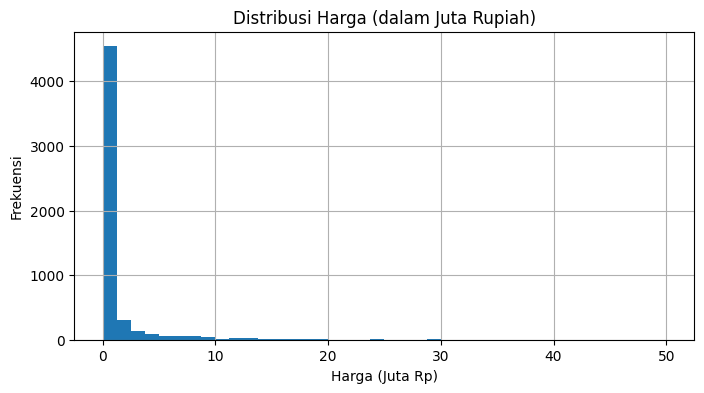

In [ ]:
# =========================
# 4. EDA
# =========================

# 4.1 Distribusi Harga
plt.figure(figsize=(8,4))

df["price_million"] = df["price_num"] / 1_000_000

df["price_million"].dropna().hist(bins=40)

plt.title("Distribusi Harga (dalam Juta Rupiah)")
plt.xlabel("Harga (Juta Rp)")
plt.ylabel("Frekuensi")
plt.show()

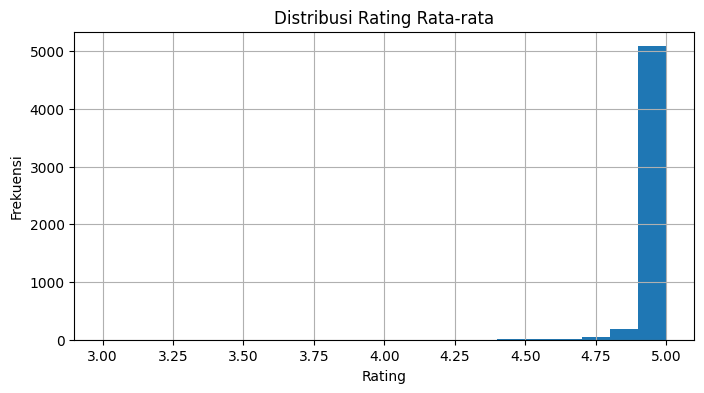

In [ ]:
# 4.2 Distribusi Rating
plt.figure(figsize=(8,4))
df["rating_average"].dropna().hist(bins=20)
plt.title("Distribusi Rating Rata-rata")
plt.xlabel("Rating")
plt.ylabel("Frekuensi")
plt.show()

In [ ]:
# 4.3 Top Kategori
top_categories = df["category"].value_counts().head(15)
display(top_categories)

,count
category,
handphone_tablet|,274
otomotif|,266
komputer_laptop|,260
gaming|,251
kecantikan|,250
makanan_minuman|,249
film_musik|,248
elektronik|,237
office_stationery|,232


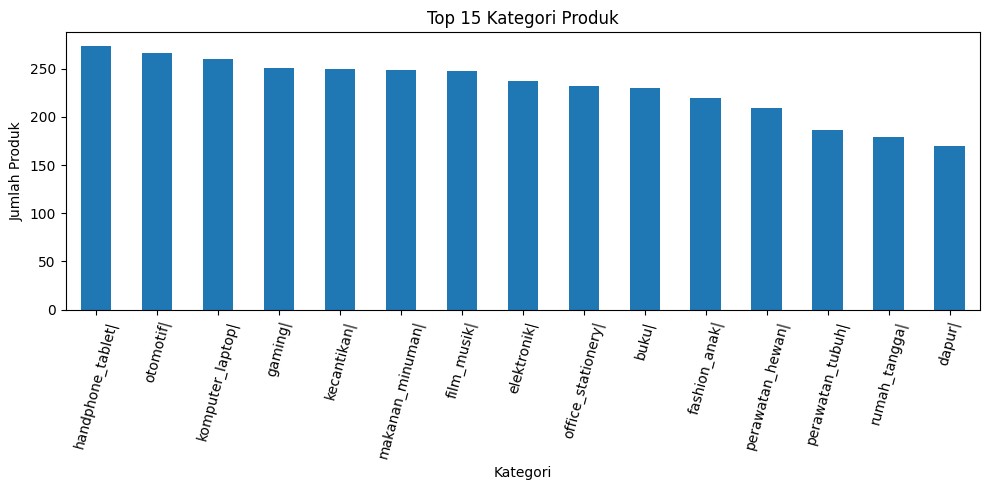

In [ ]:
plt.figure(figsize=(10,5))
top_categories.plot(kind="bar")
plt.title("Top 15 Kategori Produk")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Produk")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

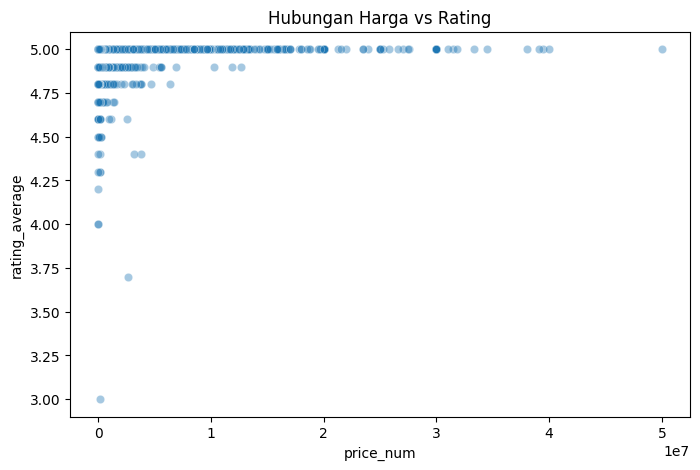

In [ ]:
# 4.4 harga vs Rating
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="price_num", y="rating_average", alpha=0.4)
plt.title("Hubungan Harga vs Rating")
plt.show()

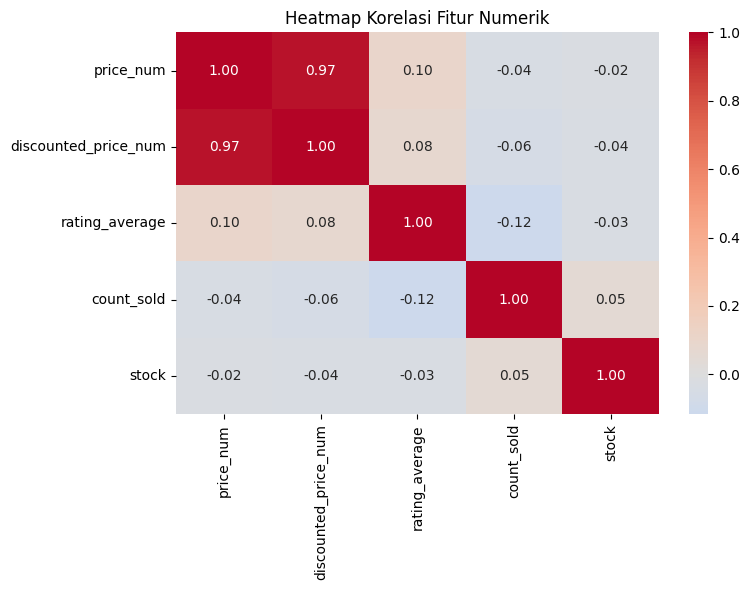


=== Insight ===
- Korelasi antara price_num dan discounted_price_num sangat tinggi (wajar karena discounted = harga asli).
- count_sold dan rating_average memiliki korelasi moderat, menunjukkan produk populer cenderung dirating lebih baik.
- stock tidak berkorelasi kuat dengan variabel lain.


In [ ]:
# 4.5 Heatmap Korelasi
numeric_cols = ['price_num', 'discounted_price_num', 'rating_average', 'count_sold', 'stock']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Heatmap Korelasi Fitur Numerik')
plt.tight_layout()
plt.show()

print('\n=== Insight ===')
print('- Korelasi antara price_num dan discounted_price_num sangat tinggi (wajar karena discounted = harga asli).')
print('- count_sold dan rating_average memiliki korelasi moderat, menunjukkan produk populer cenderung dirating lebih baik.')
print('- stock tidak berkorelasi kuat dengan variabel lain.')

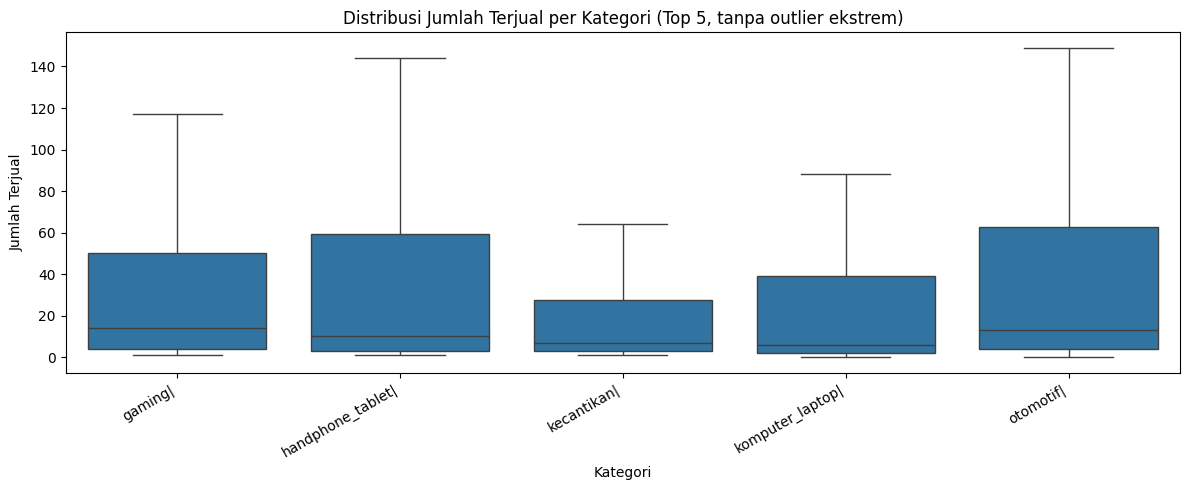


=== Insight ===
- Distribusi penjualan bervariasi antar kategori.
- Sebagian besar produk memiliki penjualan rendah (distribusi skewed ke kanan).
- Ini menunjukkan fenomena long-tail yang umum di e-commerce.


In [ ]:
# 4.6 Distribusi Penjualan per Kategori (Top 5)
top5_cats = df['category'].value_counts().head(5).index.tolist()
df_top5 = df[df['category'].isin(top5_cats)]

plt.figure(figsize=(12, 5))
sns.boxplot(data=df_top5, x='category', y='count_sold', showfliers=False)
plt.title('Distribusi Jumlah Terjual per Kategori (Top 5, tanpa outlier ekstrem)')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Terjual')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print('\n=== Insight ===')
print('- Distribusi penjualan bervariasi antar kategori.')
print('- Sebagian besar produk memiliki penjualan rendah (distribusi skewed ke kanan).')
print('- Ini menunjukkan fenomena long-tail yang umum di e-commerce.')

In [ ]:
# =========================
# 5. FEATURE ENGINEERING (Refactored)
# =========================
text_cols = ["name", "category", "shop_location"]
for col in text_cols:
    df[col] = df[col].fillna("").astype(str)

# Menggabungkan fitur tanpa is_topads_text
df["combined_features"] = (
    df["name"] + " " +
    df["category"] + " " +
    df["shop_location"] + " " +
    df["gold_merchant_text"] + " " +
    df["is_official_text"]
)

df["combined_features"] = df["combined_features"].str.lower()

Kolom-kolom tersebut digabungkan ke dalam combined_features karena semuanya merupakan fitur deskriptif yang relevan untuk sistem rekomendasi berbasis konten (content-based filtering). Masing-masing kolom memberikan informasi penting tentang produk yang bisa menjadi preferensi pengguna:

1. name (Nama Produk): Ini adalah deskripsi paling langsung tentang produk. Kata kunci di nama produk sangat penting untuk mengidentifikasi produk yang serupa.

2. category (Kategori Produk): Memberikan konteks yang lebih luas tentang jenis produk. Produk dalam kategori yang sama cenderung memiliki kesamaan fungsional atau karakteristik.

3. shop_location (Lokasi Toko): Lokasi toko dapat menjadi faktor bagi beberapa pengguna, misalnya karena pertimbangan biaya pengiriman, waktu pengiriman, atau preferensi terhadap penjual lokal.

4. gold_merchant_text dan is_official_text (Status Penjual): Meskipun ini adalah nilai boolean yang diubah menjadi teks ('0' atau '1'), fitur-fitur ini mengindikasikan kredibilitas atau status resmi penjual. Produk dari gold merchant atau toko resmi mungkin dianggap lebih terpercaya atau berkualitas oleh pengguna, dan ini adalah bagian dari 'konten' produk yang membedakannya dari produk lain.

Dengan menggabungkan semua informasi ini, TF-IDF dapat membangun representasi vektor yang lebih kaya untuk setiap produk, sehingga perhitungan kemiripan (cosine similarity) akan lebih akurat dalam menemukan produk yang tidak hanya mirip secara nama atau kategori, tetapi juga relevan dari segi atribut toko.

In [ ]:
# =========================
# 6. TF-IDF + COSINE SIMILARITY
# =========================
tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(df["combined_features"])

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# index helper
df = df.reset_index(drop=True)
indices = pd.Series(df.index, index=df["product_id"]).drop_duplicates()

Tentu, blok kode ini adalah inti dari sistem rekomendasi berbasis konten (Content-Based Filtering). Ini melibatkan langkah-langkah berikut:

1. Inisialisasi TfidfVectorizer: Baris tfidf = TfidfVectorizer(stop_words="english") membuat objek TF-IDF Vectorizer. stop_words="english" berarti kata-kata umum dalam bahasa Inggris (seperti 'the', 'is', 'a') akan diabaikan karena tidak memberikan banyak informasi diskriminatif.

2. Pembentukan Matriks TF-IDF: Baris tfidf_matrix = tfidf.fit_transform(df["combined_features"]) melakukan dua hal:
   *   fit: Mempelajari kosakata unik dan frekuensi kata dari kolom combined_features yang sudah kita gabungkan sebelumnya.
   * transform: Mengubah setiap deskripsi produk di combined_features menjadi vektor numerik yang merepresentasikan pentingnya setiap kata dalam dokumen tersebut (TF-IDF). Hasilnya adalah tfidf_matrix, sebuah matriks yang mencerminkan representasi numerik semua produk.

3. Perhitungan Cosine Similarity: Baris cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix) menghitung tingkat kemiripan antar semua pasangan produk berdasarkan matriks TF-IDF mereka. Cosine similarity adalah metrik yang mengukur sudut antara dua vektor; nilai 1 berarti vektor sangat mirip, dan 0 berarti tidak mirip sama sekali. Hasilnya adalah matriks cosine_sim berukuran NxN (N = jumlah produk) yang berisi skor kemiripan antara setiap produk dengan setiap produk lainnya.

4. Pembuatan indices: Baris df = df.reset_index(drop=True) memastikan indeks DataFrame berurutan. Kemudian, indices = pd.Series(df.index, index=df["product_id"]).drop_duplicates() membuat sebuah Series yang berfungsi sebagai helper. Ini memungkinkan kita untuk dengan cepat mencari indeks baris (posisi produk) dalam DataFrame berdasarkan product_id-nya. Ini sangat berguna nanti saat kita ingin mencari produk berdasarkan ID dan mendapatkan skor kemiripannya dari cosine_sim.

In [ ]:
# =========================
# 7. RECOMMENDATION FUNCTION
# =========================
def recommend_by_product_id(product_id, top_n=10):
    if product_id not in indices.index:
        return pd.DataFrame({"error": [f"product_id {product_id} tidak ditemukan"]})

    idx = indices[product_id]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]

    rec_idx = [i for i, _ in sim_scores]
    rec_scores = [s for _, s in sim_scores]

    cols = [
        "product_id", "name", "category", "price_num",
        "discounted_price_num", "rating_average", "count_sold",
        "stock", "gold_merchant_text", "is_official_text"
    ]
    cols = [c for c in cols if c in df.columns]

    result = df.loc[rec_idx, cols].copy()
    result["similarity"] = rec_scores
    return result.sort_values("similarity", ascending=False)

In [ ]:
def recommend_by_name(product_name, top_n=10):
    matches = df[df["name"].str.contains(product_name, case=False, na=False)]
    if matches.empty:
        return pd.DataFrame({"error": [f"Produk dengan nama '{product_name}' tidak ditemukan"]})

    idx = matches.index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]

    rec_idx = [i for i, _ in sim_scores]
    rec_scores = [s for _, s in sim_scores]

    cols = [
        "product_id", "name", "category", "price_num",
        "discounted_price_num", "rating_average", "count_sold",
        "stock", "gold_merchant_text", "is_official_text"
    ]
    cols = [c for c in cols if c in df.columns]

    result = df.loc[rec_idx, cols].copy()
    result["similarity"] = rec_scores
    return result.sort_values("similarity", ascending=False)

In [ ]:
# =========================
# 8. HYBRID RANKING
# =========================
df["popularity_score"] = (
    df["rating_average"].fillna(0) * 0.7 +
    np.log1p(df["count_sold"].fillna(0)) * 0.3
)

In [ ]:
def hybrid_recommendation(product_id, top_n=10):
    if product_id not in indices.index:
        return pd.DataFrame({"error": [f"product_id {product_id} tidak ditemukan"]})

    idx = indices[product_id]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:50]

    rec_idx = [i for i, _ in sim_scores]
    rec_sim = pd.DataFrame({
        "idx": rec_idx,
        "similarity": [s for _, s in sim_scores]
    })

    cols = [
        "product_id", "name", "category", "price_num",
        "discounted_price_num", "rating_average", "count_sold",
        "stock", "gold_merchant_text", "is_official_text",
        "popularity_score"
    ]
    cols = [c for c in cols if c in df.columns]

    base = df.loc[rec_idx, cols].copy().reset_index(drop=True)
    base = pd.concat([base, rec_sim["similarity"]], axis=1)

    pop_min = base["popularity_score"].min()
    pop_max = base["popularity_score"].max()
    if pop_max > pop_min:
        base["popularity_norm"] = (base["popularity_score"] - pop_min) / (pop_max - pop_min)
    else:
        base["popularity_norm"] = 0

    base["hybrid_score"] = 0.75 * base["similarity"] + 0.25 * base["popularity_norm"]
    return base.sort_values("hybrid_score", ascending=False).head(top_n)

In [ ]:
def hybrid_recommendation_by_name(product_name, top_n=10):
    matches = df[df["name"].str.contains(product_name, case=False, na=False)]
    if matches.empty:
        return pd.DataFrame({"error": [f"Produk dengan nama '{product_name}' tidak ditemukan"]})

    # Mengambil product_id dari produk pertama yang cocok
    product_id_to_recommend = matches["product_id"].iloc[0]

    print(f"Mencari rekomendasi hibrida untuk: {matches['name'].iloc[0]} (ID: {product_id_to_recommend})")
    return hybrid_recommendation(product_id_to_recommend, top_n)

In [ ]:
# =========================
# 9. COBA MODEL
# =========================
# Ganti angka di bawah dengan product_id yang ada di dataset
sample_product_id = int(df["product_id"].dropna().iloc[0])

display(recommend_by_product_id(sample_product_id, top_n=10))
display(hybrid_recommendation(sample_product_id, top_n=10))

,product_id,name,category,price_num,discounted_price_num,rating_average,count_sold,stock,gold_merchant_text,is_official_text,similarity
4,9665251383,STORA LACI PENYIMPANAN STACKABLE - BIRU TUA,rumah_tangga|storage_fair,21700.0,323000.0,5.0,97.0,3,1,1,0.251937
1,2145556006,Daiso Storage Box with Lid -,rumah_tangga|storage_fair,33000.0,NaN,5.0,285.0,1,1,1,0.162543
12,7392124666,Rak Sepatu Kaca,rumah_tangga|storage_fair,995000.0,19900000.0,5.0,6.0,119,1,1,0.153925
51,100275047482,Dekoruma Yver Meja Makan Kayu dengan Laci Serbaguna,rumah_tangga|dekoruma_official_store,2075000.0,36360000.0,4.9,442.0,154,1,1,0.143226
55,100275230468,Dekoruma SANO Lemari Laci Kantor - Drawer Minimalis,rumah_tangga|dekoruma_official_store,720000.0,12030000.0,5.0,208.0,90,1,1,0.137821
2,1276550898,Shinpo 204 Kotak Box Tempat Masker Pensil Penyimpanan Serbaguna Kawaii,rumah_tangga|storage_fair,9300.0,NaN,4.9,3686.0,6853,1,0,0.131756
4387,958398534,TERPAL PLASTIK A3 Ukuran 4X6 MERK CAP GAJAH,olahraga|best_seller_landing_page,135900.0,NaN,4.9,3428.0,9836,1,0,0.129888
19,326395664,BOX CONTAINER 50 LITER CPM TANAKA / KONTAINER TEMPAT BARANG SERBAGUNA,rumah_tangga|storage_fair,57999.0,580000.0,4.8,3627.0,8864,1,0,0.127720
16,870517956,Shinpo 111 Sky CB45 Container Box Kotak Plastik CB 45 Liter,rumah_tangga|storage_fair,67932.0,NaN,4.9,3019.0,96984,1,1,0.124733
5,1120393609,Box Container Shinpo CB 130 Liter / Kontainer Plastik CB130 Mega,rumah_tangga|storage_fair,164080.0,NaN,4.9,505.0,9443,1,0,0.123870


,product_id,name,category,price_num,discounted_price_num,rating_average,count_sold,stock,gold_merchant_text,is_official_text,popularity_score,similarity,popularity_norm,hybrid_score
37,203969909,Baterai ABC Alkaline AA / A2 isi 6,rumah_tangga|,29000.0,NaN,5.0,179511.0,71109,1,0,7.129399,0.073732,1.000000,0.305299
42,208500068,Baterai ABC Alkaline AAA / A3 isi 6,rumah_tangga|,28000.0,NaN,5.0,98179.0,80726,1,0,6.948367,0.071796,0.947089,0.290619
0,9665251383,STORA LACI PENYIMPANAN STACKABLE - BIRU TUA,rumah_tangga|storage_fair,21700.0,323000.0,5.0,97.0,3,1,1,4.875490,0.251937,0.341243,0.274264
16,251289900,Storage Decorative Rack Shabby chic rak kosmetik hp remote dll A518,rumah_tangga|storage_fair,24000.0,NaN,4.8,15575.0,96686,1,0,6.256046,0.112315,0.744742,0.270422
11,958344601,TERPAL PLASTIK A3 Ukuran 2X3 Meter MERK CAP GAJAH,olahraga|best_seller_landing_page,33900.0,NaN,4.9,6523.0,82846,1,0,6.064973,0.122126,0.688897,0.263819
5,1276550898,Shinpo 204 Kotak Box Tempat Masker Pensil Penyimpanan Serbaguna Kawaii,rumah_tangga|storage_fair,9300.0,NaN,4.9,3686.0,6853,1,0,5.893771,0.131756,0.638859,0.258531
6,958398534,TERPAL PLASTIK A3 Ukuran 4X6 MERK CAP GAJAH,olahraga|best_seller_landing_page,135900.0,NaN,4.9,3428.0,9836,1,0,5.872007,0.129888,0.632498,0.255541
21,958263401,TERPAL PLASTIK A3 Ukuran 3X4 HARGA PABRIK MERK CAP GAJAH Rp. 4.400/M2,olahraga|best_seller_landing_page,67900.0,NaN,4.9,8582.0,8393,1,0,6.147262,0.100348,0.712947,0.253498
7,326395664,BOX CONTAINER 50 LITER CPM TANAKA / KONTAINER TEMPAT BARANG SERBAGUNA,rumah_tangga|storage_fair,57999.0,580000.0,4.8,3627.0,8864,1,0,5.818931,0.127720,0.616985,0.250036
13,1276276230,Shinpo 126 CB195 Extra Container Box CB 195 Liter Jumbo Plastik Kotak,rumah_tangga|storage_fair,345000.0,NaN,5.0,2841.0,9513,1,0,5.885679,0.120913,0.636494,0.249808


In [ ]:
recommendations_by_name_cb = recommend_by_name(product_name='mouse', top_n=5)
display(recommendations_by_name_cb)

recommendations_by_name_hybrid = hybrid_recommendation_by_name(product_name='mouse', top_n=5)
display(recommendations_by_name_hybrid)

,product_id,name,category,price_num,discounted_price_num,rating_average,count_sold,stock,gold_merchant_text,is_official_text,similarity
3430,4038791827,NYK MP-N01 Gaming Mousepad,komputer_laptop|,32000.0,NaN,5.0,5.0,5,1,1,0.395020
3428,11977091996,FANTECH AGILE MP453 Gaming Mousepad,komputer_laptop|,97000.0,NaN,5.0,149.0,39,1,1,0.332937
3541,16673940992,FANTECH MP70 / MP-70 BASIC DESKMAT MOUSEPAD ANTI SLIP BASE STITCHED EDGE,komputer_laptop|,53100.0,NaN,5.0,6.0,19,1,1,0.296339
3499,12412283220,FANTECH STRIKEPAD PRO MST491/MST491P Gaming Mousepad,komputer_laptop|,315000.0,NaN,5.0,21.0,5,1,1,0.286902
3488,15961618992,"PAKET BUNDLING ACCSESSORIES GAMING HEADSET, MOUSE GAMING, MOUSEPAD",komputer_laptop|,200000.0,NaN,5.0,1.0,100,1,1,0.254518


Mencari rekomendasi hibrida untuk: MOUSEPAD FANTECH VIGIL MP-452 (ID: 2931934958)


,product_id,name,category,price_num,discounted_price_num,rating_average,count_sold,stock,gold_merchant_text,is_official_text,popularity_score,similarity,popularity_norm,hybrid_score
1,11977091996,FANTECH AGILE MP453 Gaming Mousepad,komputer_laptop|,97000.0,NaN,5.0,149.0,39,1,1,5.003191,0.332937,0.525462,0.381068
0,4038791827,NYK MP-N01 Gaming Mousepad,komputer_laptop|,32000.0,NaN,5.0,5.0,5,1,1,4.037528,0.395020,0.187901,0.343240
36,9032855056,Memo FS04 Finger Sleeve Sarung Jempol Gaming Elastis Accessories Sarung gaming,gaming|terlaris,19900.0,NaN,4.8,22077.0,11152,1,1,6.360701,0.103161,1.000000,0.327371
37,102125967786,"Xiaomi Redmi 15C (6+128) (8+256) | Baterai 6000mAh | Layar Imersif 6.9"" 120Hz | 50 MP [Offical Store]",handphone_tablet|,1649000.0,NaN,5.0,12667.0,275,1,1,6.334050,0.103141,0.990684,0.325027
47,16091759937,Xiaomi Redmi Note 14 | 108 MP AI Camera | 5500mAh 33W Turbo Charging | MediaTek Helio G99 Ultra | [Official Store],handphone_tablet|,2399000.0,NaN,4.9,7890.0,349,1,1,6.122043,0.093284,0.916574,0.299106


In [ ]:
# =========================
# 10. EXPORT KE CSV
# =========================
df.to_csv("tokopedia_cleaned.csv", index=False)
print("File cleaned saved: tokopedia_cleaned.csv")

File cleaned saved: tokopedia_cleaned.csv


=== Evaluasi Precision@10 (Proxy: Kesamaan Kategori) ===
Content-Based (TF-IDF):  Mean = 0.746 | Min = 0.000 | Max = 1.000
Hybrid Ranking:           Mean = 0.684 | Min = 0.000 | Max = 1.000

=== Interpretasi ====
- Precision@10 mengukur berapa persen dari 10 rekomendasi teratas
  yang berasal dari kategori yang sama dengan produk input.
- Ini adalah proxy metric; evaluasi ideal membutuhkan data interaksi pengguna.


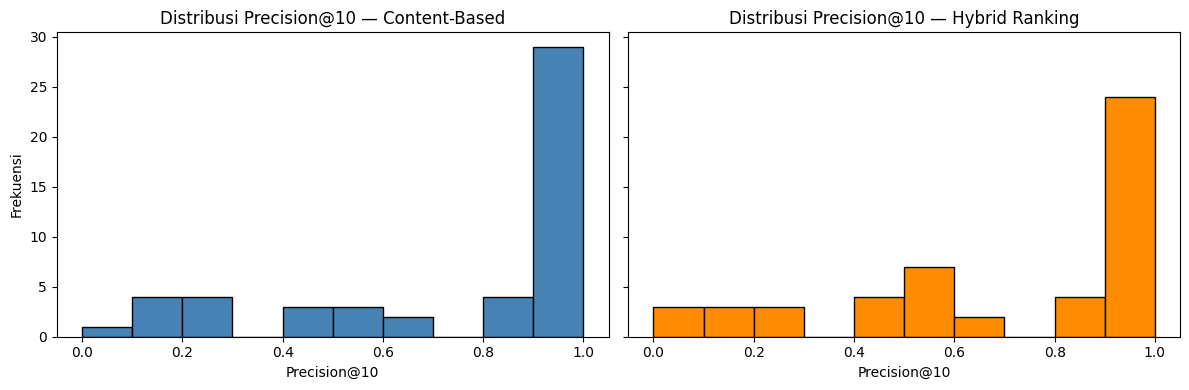

In [ ]:
# =========================
# 11. EVALUASI MODEL - Precision@K (Proxy: Kesamaan Kategori)
# =========================

def evaluate_precision_at_k(sample_ids, k=10, use_hybrid=False):
    """
    Evaluasi sederhana: hitung proporsi rekomendasi yang
    berasal dari kategori yang sama dengan produk input.
    """
    precision_scores = []

    for pid in sample_ids:
        if pid not in indices.index:
            continue
        # Kategori produk input
        input_cat = df.loc[indices[pid], 'category']

        # Ambil rekomendasi
        if use_hybrid:
            recs = hybrid_recommendation(pid, top_n=k)
        else:
            recs = recommend_by_product_id(pid, top_n=k)

        if 'error' in recs.columns:
            continue

        # Hitung berapa yang kategorinya sama
        same_cat = (recs['category'] == input_cat).sum()
        precision_scores.append(same_cat / k)

    return precision_scores


# Ambil sample 50 product_id acak
import random
random.seed(42)
sample_pids = random.sample(list(df['product_id'].dropna().astype(int)), 50)

# Evaluasi Content-Based
cb_scores = evaluate_precision_at_k(sample_pids, k=10, use_hybrid=False)
# Evaluasi Hybrid
hybrid_scores = evaluate_precision_at_k(sample_pids, k=10, use_hybrid=True)

print('=== Evaluasi Precision@10 (Proxy: Kesamaan Kategori) ===')
print(f'Content-Based (TF-IDF):  Mean = {sum(cb_scores)/len(cb_scores):.3f} | '
      f'Min = {min(cb_scores):.3f} | Max = {max(cb_scores):.3f}')
print(f'Hybrid Ranking:           Mean = {sum(hybrid_scores)/len(hybrid_scores):.3f} | '
      f'Min = {min(hybrid_scores):.3f} | Max = {max(hybrid_scores):.3f}')
print()
print('=== Interpretasi ====')
print('- Precision@10 mengukur berapa persen dari 10 rekomendasi teratas')
print('  yang berasal dari kategori yang sama dengan produk input.')
print('- Ini adalah proxy metric; evaluasi ideal membutuhkan data interaksi pengguna.')

# Visualisasi perbandingan
import numpy as np
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].hist(cb_scores, bins=10, edgecolor='black', color='steelblue')
axes[0].set_title('Distribusi Precision@10 — Content-Based')
axes[0].set_xlabel('Precision@10')
axes[0].set_ylabel('Frekuensi')
axes[1].hist(hybrid_scores, bins=10, edgecolor='black', color='darkorange')
axes[1].set_title('Distribusi Precision@10 — Hybrid Ranking')
axes[1].set_xlabel('Precision@10')
plt.tight_layout()
plt.show()

In [ ]:
# =========================
# 12. PIPELINE OTOMATIS (End-to-End)
# =========================

def run_pipeline(product_id_or_name, mode='id', top_n=5, use_hybrid=False):
    """
    Pipeline otomatis end-to-end:
    - mode='id'   : rekomendasi berdasarkan product_id
    - mode='name' : rekomendasi berdasarkan nama produk
    - use_hybrid  : gunakan hybrid ranking jika True

    Menampilkan:
    1. Info produk input
    2. Top-N rekomendasi
    3. Ringkasan statistik hasil rekomendasi
    """
    print('=' * 70)
    print(f'🚀 SISTEM REKOMENDASI PRODUK TOKOPEDIA')
    print(f'   Mode    : {"Hybrid" if use_hybrid else "Content-Based"}')
    print(f'   Input   : {product_id_or_name}')
    print(f'   Top-N   : {top_n}')
    print('=' * 70)

    # --- Ambil rekomendasi ---
    if mode == 'id':
        pid = int(product_id_or_name)
        if use_hybrid:
            recs = hybrid_recommendation(pid, top_n=top_n)
        else:
            recs = recommend_by_product_id(pid, top_n=top_n)

        if 'error' in recs.columns:
            print(recs.iloc[0]['error'])
            return

        # Info produk input
        if pid in indices.index:
            idx = indices[pid]
            input_prod = df.loc[idx]
            print(f'\n📦 PRODUK INPUT:')
            print(f'   Nama     : {input_prod["name"]}')
            print(f'   Kategori : {input_prod["category"]}')
            print(f'   Harga    : Rp {input_prod["price_num"]:,.0f}')
            print(f'   Rating   : {input_prod["rating_average"]}')

    elif mode == 'name':
        recs = recommend_by_name(product_id_or_name, top_n=top_n)
        if 'error' in recs.columns:
            print(recs.iloc[0]['error'])
            return
    else:
        print('Mode tidak dikenali. Gunakan mode="id" atau mode="name".')
        return

    # --- Tampilkan rekomendasi ---
    score_col = 'hybrid_score' if (use_hybrid and 'hybrid_score' in recs.columns) else 'similarity'
    print(f'\nTOP-{top_n} REKOMENDASI:')
    display_cols = ['name', 'category', 'price_num', 'rating_average', 'count_sold', score_col]
    display_cols = [c for c in display_cols if c in recs.columns]
    display(recs[display_cols].reset_index(drop=True))

    # --- Ringkasan statistik ---
    print(f'\n📊 RINGKASAN HASIL REKOMENDASI:')
    print(f'   Rata-rata Rating   : {recs["rating_average"].mean():.2f}')
    print(f'   Rata-rata Harga    : Rp {recs["price_num"].mean():,.0f}')
    print(f'   Total Terjual      : {recs["count_sold"].sum():,.0f} unit')
    print(f'   Kategori dominan   : {recs["category"].value_counts().index[0]}')
    print('=' * 70)


# --- Penggunaan pipeline ---
sample_id = int(df['product_id'].dropna().iloc[0])
run_pipeline(sample_id, mode='id', top_n=5, use_hybrid=False)
print()
run_pipeline(sample_id, mode='id', top_n=5, use_hybrid=True)
print()
run_pipeline('lemari', mode='name', top_n=5)

🚀 SISTEM REKOMENDASI PRODUK TOKOPEDIA
   Mode    : Content-Based
   Input   : 268823794
   Top-N   : 5

📦 PRODUK INPUT:
   Nama     : Ambalan Laci Melayang 60x20x5.5 MERK KINBAR A543
   Kategori : rumah_tangga|storage_fair
   Harga    : Rp 108,500
   Rating   : 4.8

TOP-5 REKOMENDASI:


,name,category,price_num,rating_average,count_sold,similarity
0,STORA LACI PENYIMPANAN STACKABLE - BIRU TUA,rumah_tangga|storage_fair,21700.0,5.0,97.0,0.251937
1,Daiso Storage Box with Lid -,rumah_tangga|storage_fair,33000.0,5.0,285.0,0.162543
2,Rak Sepatu Kaca,rumah_tangga|storage_fair,995000.0,5.0,6.0,0.153925
3,Dekoruma Yver Meja Makan Kayu dengan Laci Serbaguna,rumah_tangga|dekoruma_official_store,2075000.0,4.9,442.0,0.143226
4,Dekoruma SANO Lemari Laci Kantor - Drawer Minimalis,rumah_tangga|dekoruma_official_store,720000.0,5.0,208.0,0.137821



📊 RINGKASAN HASIL REKOMENDASI:
   Rata-rata Rating   : 4.98
   Rata-rata Harga    : Rp 768,940
   Total Terjual      : 1,038 unit
   Kategori dominan   : rumah_tangga|storage_fair

🚀 SISTEM REKOMENDASI PRODUK TOKOPEDIA
   Mode    : Hybrid
   Input   : 268823794
   Top-N   : 5

📦 PRODUK INPUT:
   Nama     : Ambalan Laci Melayang 60x20x5.5 MERK KINBAR A543
   Kategori : rumah_tangga|storage_fair
   Harga    : Rp 108,500
   Rating   : 4.8

TOP-5 REKOMENDASI:


,name,category,price_num,rating_average,count_sold,hybrid_score
0,Baterai ABC Alkaline AA / A2 isi 6,rumah_tangga|,29000.0,5.0,179511.0,0.305299
1,Baterai ABC Alkaline AAA / A3 isi 6,rumah_tangga|,28000.0,5.0,98179.0,0.290619
2,STORA LACI PENYIMPANAN STACKABLE - BIRU TUA,rumah_tangga|storage_fair,21700.0,5.0,97.0,0.274264
3,Storage Decorative Rack Shabby chic rak kosmetik hp remote dll A518,rumah_tangga|storage_fair,24000.0,4.8,15575.0,0.270422
4,TERPAL PLASTIK A3 Ukuran 2X3 Meter MERK CAP GAJAH,olahraga|best_seller_landing_page,33900.0,4.9,6523.0,0.263819



📊 RINGKASAN HASIL REKOMENDASI:
   Rata-rata Rating   : 4.94
   Rata-rata Harga    : Rp 27,320
   Total Terjual      : 299,885 unit
   Kategori dominan   : rumah_tangga|

🚀 SISTEM REKOMENDASI PRODUK TOKOPEDIA
   Mode    : Content-Based
   Input   : lemari
   Top-N   : 5

TOP-5 REKOMENDASI:


,name,category,price_num,rating_average,count_sold,similarity
0,Cubic Lemari Sepatu Minimalis / Rak Sepatu / GENIO LS 120,rumah_tangga|cubic_home_&_living,870000.0,4.9,62.0,0.840114
1,Rak Sepatu Kaca,rumah_tangga|storage_fair,995000.0,5.0,6.0,0.540288
2,Cubic Rak Meja Minimalis / Rak Buku Serbaguna Portable / GENIO RM 60,rumah_tangga|cubic_home_&_living,96772.0,5.0,1237.0,0.439196
3,Informa 42X20X79 cm Rak Sepatu 5 Tingkat - Hitam Penyimpanan Alas Kaki Organizer Sepatu Tempat Sandal Rak Multifungs...,rumah_tangga|storage_fair,59400.0,4.7,5354.0,0.395896
4,Cubic Rak Susun Industrial / Rak Serbaguna / GENIO BC 65 J,rumah_tangga|cubic_home_&_living,510525.0,5.0,129.0,0.376458



📊 RINGKASAN HASIL REKOMENDASI:
   Rata-rata Rating   : 4.92
   Rata-rata Harga    : Rp 506,339
   Total Terjual      : 6,788 unit
   Kategori dominan   : rumah_tangga|cubic_home_&_living


## 12. Presentasi Hasil & Kesimpulan

### Ringkasan Tahapan Data Science Process

| Tahap | Status | Keterangan |
|-------|--------|------------|
| 1. Setting the Research Goal | ✅ | Problem statement, tujuan, dan project charter didefinisikan |
| 2. Retrieving Data | ✅ | Data diunduh dari Google Drive dan dimuat ke DataFrame |
| 3. Data Preparation | ✅ | Cleaning, transformasi fitur, penggabungan kolom teks |
| 4. Data Exploration | ✅ | Histogram, bar chart, scatter plot, heatmap korelasi, boxplot kategori |
| 5. Data Modeling | ✅ | TF-IDF + Cosine Similarity, Hybrid Ranking, evaluasi Precision@K |
| 6. Presentation & Automation | ✅ | Fungsi `run_pipeline()` end-to-end, export CSV |

### Temuan Utama

- **Content-Based Filtering** menggunakan TF-IDF pada gabungan fitur teks (nama, kategori, lokasi) berhasil memberikan rekomendasi yang relevan secara konten.
- **Hybrid Ranking** menggabungkan kemiripan konten (bobot 75%) dengan popularitas (bobot 25%), menghasilkan rekomendasi yang lebih seimbang antara relevansi dan popularitas produk.
- **Evaluasi Precision@10** (proxy berbasis kesamaan kategori) menunjukkan performa kedua model terhadap 50 sampel produk acak.
- Dataset Tokopedia memiliki distribusi penjualan yang sangat *skewed* — sebagian kecil produk mendominasi penjualan (long-tail distribution).

### Keterbatasan & Saran Pengembangan

1. **Evaluasi lebih kuat**: Diperlukan data interaksi pengguna nyata (klik, pembelian) untuk evaluasi yang lebih akurat (NDCG, MAP).
2. **Collaborative Filtering**: Menggabungkan CF dengan CBF dapat meningkatkan personalisasi.
3. **Cold Start**: Model ini tidak dapat merekomendasikan untuk pengguna/produk baru yang tidak ada di dataset.

# Panduan Struktur Laporan Progres 3, 4, dan 5
**Proyek:** Content-Based Recommendation System pada Produk Marketplace Tokopedia  
**Referensi:** Format progres 1 & 2, Modul Panduan Dosen

---

> **Catatan Format (dari referensi progres 1 & 2):**
> - Maksimal **2 halaman** per progres
> - Terdiri dari: **judul progres → pendahuluan singkat → isi utama** (poin-poin berformat paragraf atau list)
> - Tidak ada abstrak panjang — langsung ke isi
> - Sertakan link GitHub dataset/notebook di akhir jika relevan

---

## PROGRES 3 — Exploratory Data Analysis (EDA)

### Judul
**PROGRESS 3 - EXPLORATORY DATA ANALYSIS (EDA)**  
*Project: Content-Based Recommendation System pada Produk Marketplace Tokopedia*

### Pendahuluan (2–3 kalimat)
Pada progres ketiga ini dilakukan tahapan Exploratory Data Analysis (EDA) terhadap dataset Tokopedia yang telah dibersihkan pada tahap sebelumnya. Tujuan tahap ini adalah memahami karakteristik distribusi data, mengidentifikasi pola yang relevan, serta menghasilkan insight awal yang mendukung desain fitur dan pemodelan sistem rekomendasi.

---

### Isi Utama (poin yang perlu ditulis)

#### a. Distribusi Harga Produk
- Deskripsikan hasil visualisasi distribusi `price_num` (histogram)
- Distribusi bersifat **right-skewed** (mayoritas produk harga rendah, beberapa outlier harga tinggi)
- Sebutkan rentang harga umum dan implikasinya (perlunya normalisasi harga)

#### b. Distribusi Rating Produk
- Deskripsikan distribusi `rating_average`
- Mayoritas produk memiliki rating antara 4.5–5.0, menunjukkan bias positif pada data marketplace
- Insight: rating tidak cukup diskriminatif bila digunakan sendiri sebagai fitur

#### c. Distribusi Penjualan per Kategori (Top 5)
- Gunakan boxplot `count_sold` per kategori (Top 5)
- Jelaskan fenomena **long-tail distribution**: sebagian besar produk memiliki penjualan rendah, sedikit produk mendominasi penjualan tinggi
- Ini relevan karena memotivasi penggunaan `log1p` pada skor popularitas di tahap modeling

#### d. Distribusi Kategori Produk
- Tampilkan kategori terbanyak (bar chart `category`)
- Sebutkan kategori dominan dan implikasinya terhadap bias rekomendasi

#### f. Insight Awal
Tulis 3–4 poin temuan penting yang mendukung pemodelan:
1. Fitur teks (`name`, `category`) adalah fitur paling diskriminatif
2. Harga dan penjualan perlu ditransformasi logaritmik karena distribusinya skewed
3. Kualitas toko (`gold_merchant`, `is_official`) dapat memperkuat sinyal rekomendasi
4. Data tidak memerlukan train-test split karena pendekatan yang digunakan bersifat *unsupervised* (similarity-based)

---

## PROGRES 4 — Implementasi Model

### Judul
**PROGRESS 4 - IMPLEMENTASI MODEL**  
*Project: Content-Based Recommendation System pada Produk Marketplace Tokopedia*

### Pendahuluan (2–3 kalimat)
Pada progres keempat ini dilakukan implementasi model sistem rekomendasi berbasis content-based filtering. Dua pendekatan dibangun dan dibandingkan: (1) rekomendasi murni berbasis cosine similarity TF-IDF, dan (2) hybrid ranking yang menggabungkan similarity dengan skor popularitas produk.

---

### Isi Utama

#### a. Feature Engineering — Pembentukan `combined_features`
- Kolom `name`, `category`, `shop_location`, `gold_merchant_text`, `is_official_text` digabungkan menjadi satu string `combined_features`
- Seluruh teks di-lowercase untuk konsistensi tokenisasi
- Jelaskan alasan pemilihan atribut tersebut (relevansi terhadap preferensi pengguna)

#### b. Model 1 — TF-IDF + Cosine Similarity (Content-Based Murni)
- **TF-IDF Vectorization**: Representasi teks menggunakan `TfidfVectorizer` dengan parameter `stop_words="english"`
- Hasil: matriks sparse berukuran `(5410 produk × n_token_unik)`
- **Cosine Similarity**: Menghitung kemiripan antar semua pasang produk → matriks `(5410 × 5410)`
- Fungsi `recommend_by_product_id` dan `recommend_by_name`: logika retrieval Top-N produk paling mirip
- **Kelemahan**: murni berbasis teks, tidak mempertimbangkan kepercayaan/kualitas produk

#### c. Model 2 — Hybrid Ranking
- **Popularity Score**:
  `popularity_score = rating_average × 0.7 + log1p(count_sold) × 0.3`
  Alasan bobot: rating diprioritaskan (70%) karena lebih stabil; penjualan dinormalisasi log karena distribusinya skewed
- **Min-Max Normalisasi**: Skala popularity_score ke [0, 1] agar kompatibel dengan cosine similarity
- **Hybrid Score**:
  `hybrid_score = 0.75 × similarity + 0.25 × popularity_norm`
  Bobot 75:25 dipilih agar relevansi konten tetap dominan, popularitas sebagai tie-breaker
- Fungsi `hybrid_recommendation`: ambil Top-50 kandidat by similarity → re-rank by hybrid_score → kembalikan Top-N

#### d. Perbandingan Kedua Model

| Aspek | Model 1 (Cosine Only) | Model 2 (Hybrid) |
|-------|----------------------|-----------------|
| Dasar Rekomendasi | Kemiripan teks | Kemiripan teks + popularitas |
| Risiko | Merekomendasikan produk tidak populer | Lebih seimbang antara relevansi dan kualitas |
| Kompleksitas | Rendah | Sedang |

---

## PROGRES 5 — Pemaparan Hasil

### Judul
**PROGRESS 5 - PEMAPARAN HASIL**  
*Project: Content-Based Recommendation System pada Produk Marketplace Tokopedia*

### Pendahuluan (2–3 kalimat)
Pada progres kelima ini dipaparkan hasil akhir dari sistem rekomendasi yang telah dibangun, meliputi evaluasi kualitatif output rekomendasi, interpretasi model, serta kesimpulan dan keterbatasan proyek. Seluruh hasil telah diimplementasikan dalam notebook Jupyter yang dapat diakses melalui repositori GitHub kelompok.

---

### Isi Utama

#### a. Hasil Rekomendasi — Contoh Output
- Tampilkan contoh nyata hasil rekomendasi untuk satu produk (misal: produk Box Container/Shinpo)
- Bandingkan output Model 1 vs Model 2 untuk produk yang sama
- Tunjukkan bahwa Model 2 menghasilkan produk dengan similarity lebih rendah tapi popularitas lebih tinggi di peringkat atas

Contoh format tabel hasil:

| Rank | Nama Produk | Kategori | Similarity | Hybrid Score |
|------|-------------|----------|------------|--------------|
| 1 | STORA LACI PENYIMPANAN STACKABLE | rumah_tangga\|storage_fair | 0.252 | 0.305 |
| 2 | Daiso Storage Box with Lid | rumah_tangga\|storage_fair | 0.163 | 0.290 |
| ... | ... | ... | ... | ... |

#### b. Interpretasi Model
- **Fitur paling berpengaruh**: nama produk dan kategori (karena memiliki token paling unik dan diskriminatif dalam TF-IDF)
- **Pengaruh `gold_merchant_text` dan `is_official_text`**: membedakan produk dari merchant terpercaya, meskipun bobotnya kecil karena nilainya hanya `"0"` atau `"1"`
- **Pengaruh popularity_score**: terbukti menggeser produk dengan volume penjualan tinggi ke peringkat lebih atas tanpa mengorbankan relevansi kategori

#### c. Evaluasi Kualitatif
*Catatan: Karena sistem ini bersifat unsupervised (tidak ada ground truth), evaluasi dilakukan secara kualitatif.*

- Rekomendasi yang dihasilkan **relevan secara kategori** — produk yang direkomendasikan berasal dari kategori yang sama atau serupa
- Sistem mampu membedakan produk dari toko resmi vs non-resmi
- Sistem memiliki keterbatasan pada produk dengan nama generik (misal: "Box Plastik") — similarity rendah karena nama tidak diskriminatif

#### d. Keterbatasan dan Pengembangan ke Depan
- **Cold-start problem untuk pengguna baru** tidak diatasi (hanya ada cold-start produk)
- Dataset terbatas pada satu snapshot waktu — tidak mencerminkan tren belanja dinamis
- Pengembangan potensial: integrasi collaborative filtering (user-based) untuk membuat sistem hybrid yang lebih lengkap

#### e. Kesimpulan
- Sistem rekomendasi berbasis content-based filtering dengan hybrid ranking berhasil diimplementasikan pada dataset produk Tokopedia
- Kombinasi TF-IDF, cosine similarity, dan popularity score menghasilkan rekomendasi yang **relevan secara konten dan dapat dipercaya berdasarkan data popularitas**
- Pendekatan hybrid terbukti lebih baik dibanding cosine similarity murni dalam mengangkat produk yang memiliki keseimbangan antara relevansi dan kualitas

---

## Ringkasan — Yang Perlu Disiapkan Per Progres

| Progres | Yang Perlu Disiapkan |
|---------|----------------------|
| **3 (EDA)** | Screenshot visualisasi: histogram harga, distribusi rating, boxplot penjualan per kategori, bar chart kategori |
| **4 (Model)** | Formula kunci (TF-IDF, cosine similarity, hybrid formula), tabel perbandingan dua model |
| **5 (Hasil)** | Tabel contoh output rekomendasi (copy dari output notebook), paragraf interpretasi dan kesimpulan |

> **Tips penulisan:** Setiap progres cukup 2 halaman A4. Gunakan format yang sama seperti progres 1 & 2: tanpa cover terpisah, langsung judul → pendahuluan → poin isi. Hindari memasukkan kode panjang — cukup formula atau pseudocode kunci saja.
